#  Exploratory Data Analysis (EDA)
## California Housing Dataset

### Objective:
Understand data distribution, relationships, and patterns to guide feature engineering and model building.

In [8]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

print(project_root)

C:\Users\afshe\Day18_Feature_Engineering


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [10]:
from src.load_data import load_data

In [11]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [13]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Observations:
- Dataset has no categorical features
- All features are numerical
- Target variable: `MedHouseVal`
- Some features may have skewed distributions (to verify next)

In [14]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Observation:
- No missing values present
- Dataset is clean and ready for analysis

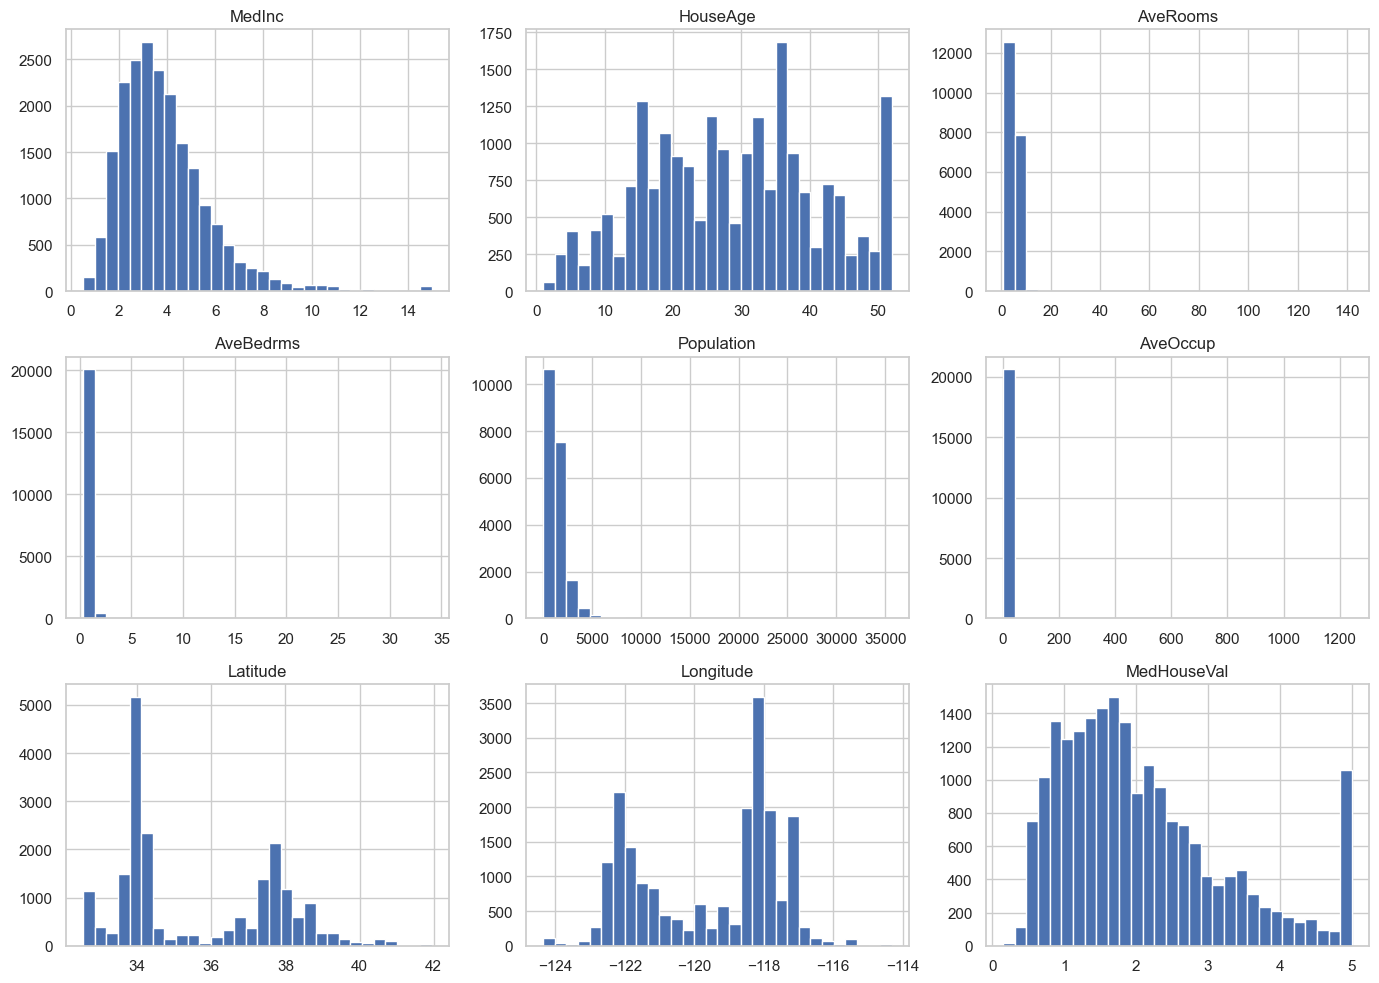

In [15]:
df.hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

### Observations:
- `MedInc` is right-skewed
- `HouseAge` has some uniform distribution
- `Population` and `AveRooms` show extreme values → possible outliers

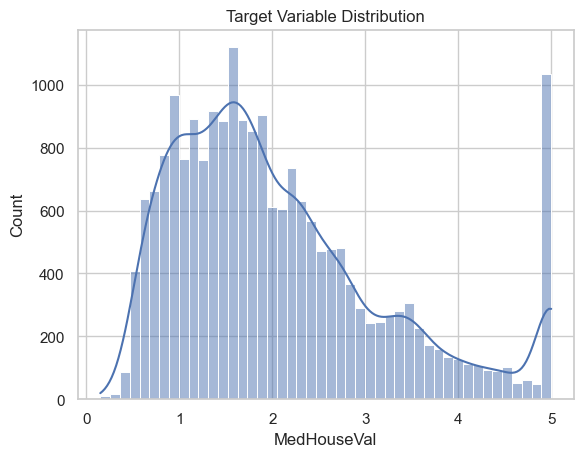

In [16]:
sns.histplot(df["MedHouseVal"], kde=True)
plt.title("Target Variable Distribution")
plt.show()

### Observation:
- Target variable is slightly skewed
- May benefit from transformation (log scaling if needed)

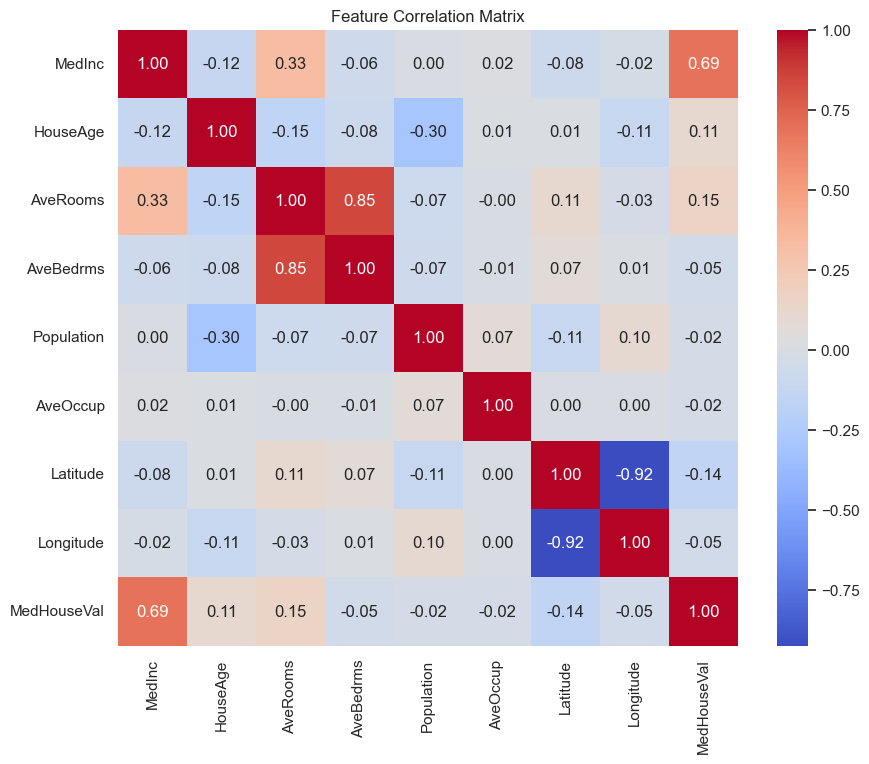

In [17]:
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

### Observations:
- `MedInc` has strong positive correlation with target
- `AveRooms` moderately correlated
- Latitude & Longitude show spatial dependency

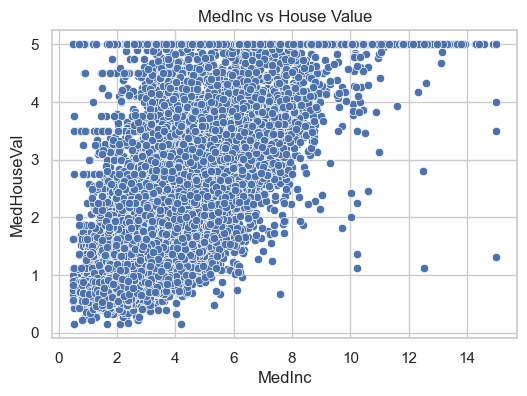

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["MedInc"], y=df["MedHouseVal"])
plt.title("MedInc vs House Value")
plt.show()

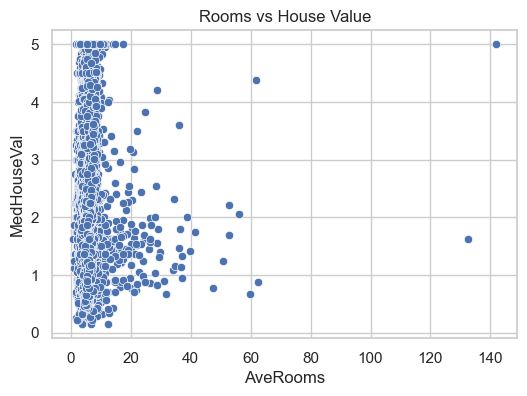

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["AveRooms"], y=df["MedHouseVal"])
plt.title("Rooms vs House Value")
plt.show()

### Observations:
- Higher income → higher house prices
- Rooms show positive trend but with noise
- Indicates need for feature interactions

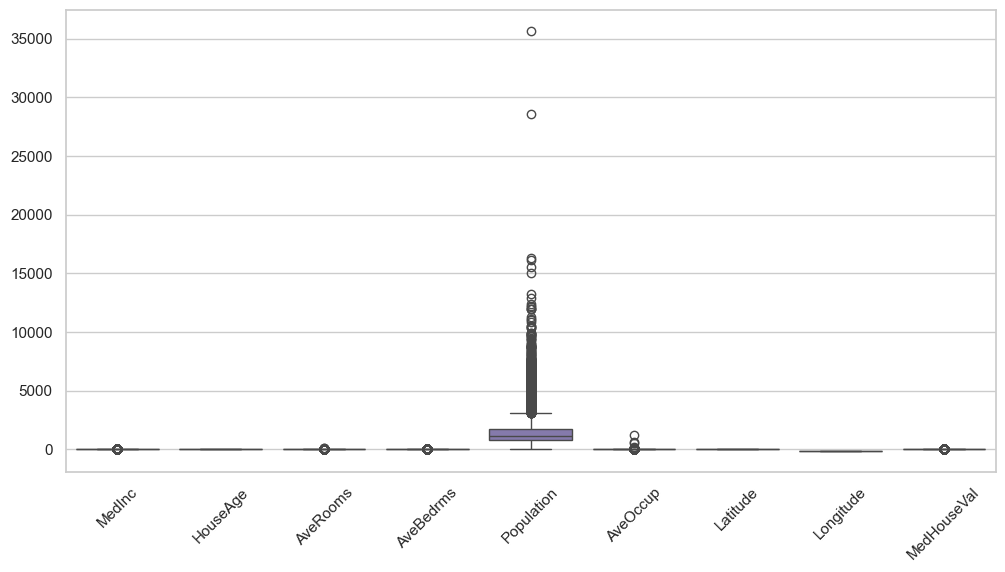

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

### Observations:
- Several features contain outliers:
  - Population
  - AveRooms
- Consider scaling or transformation

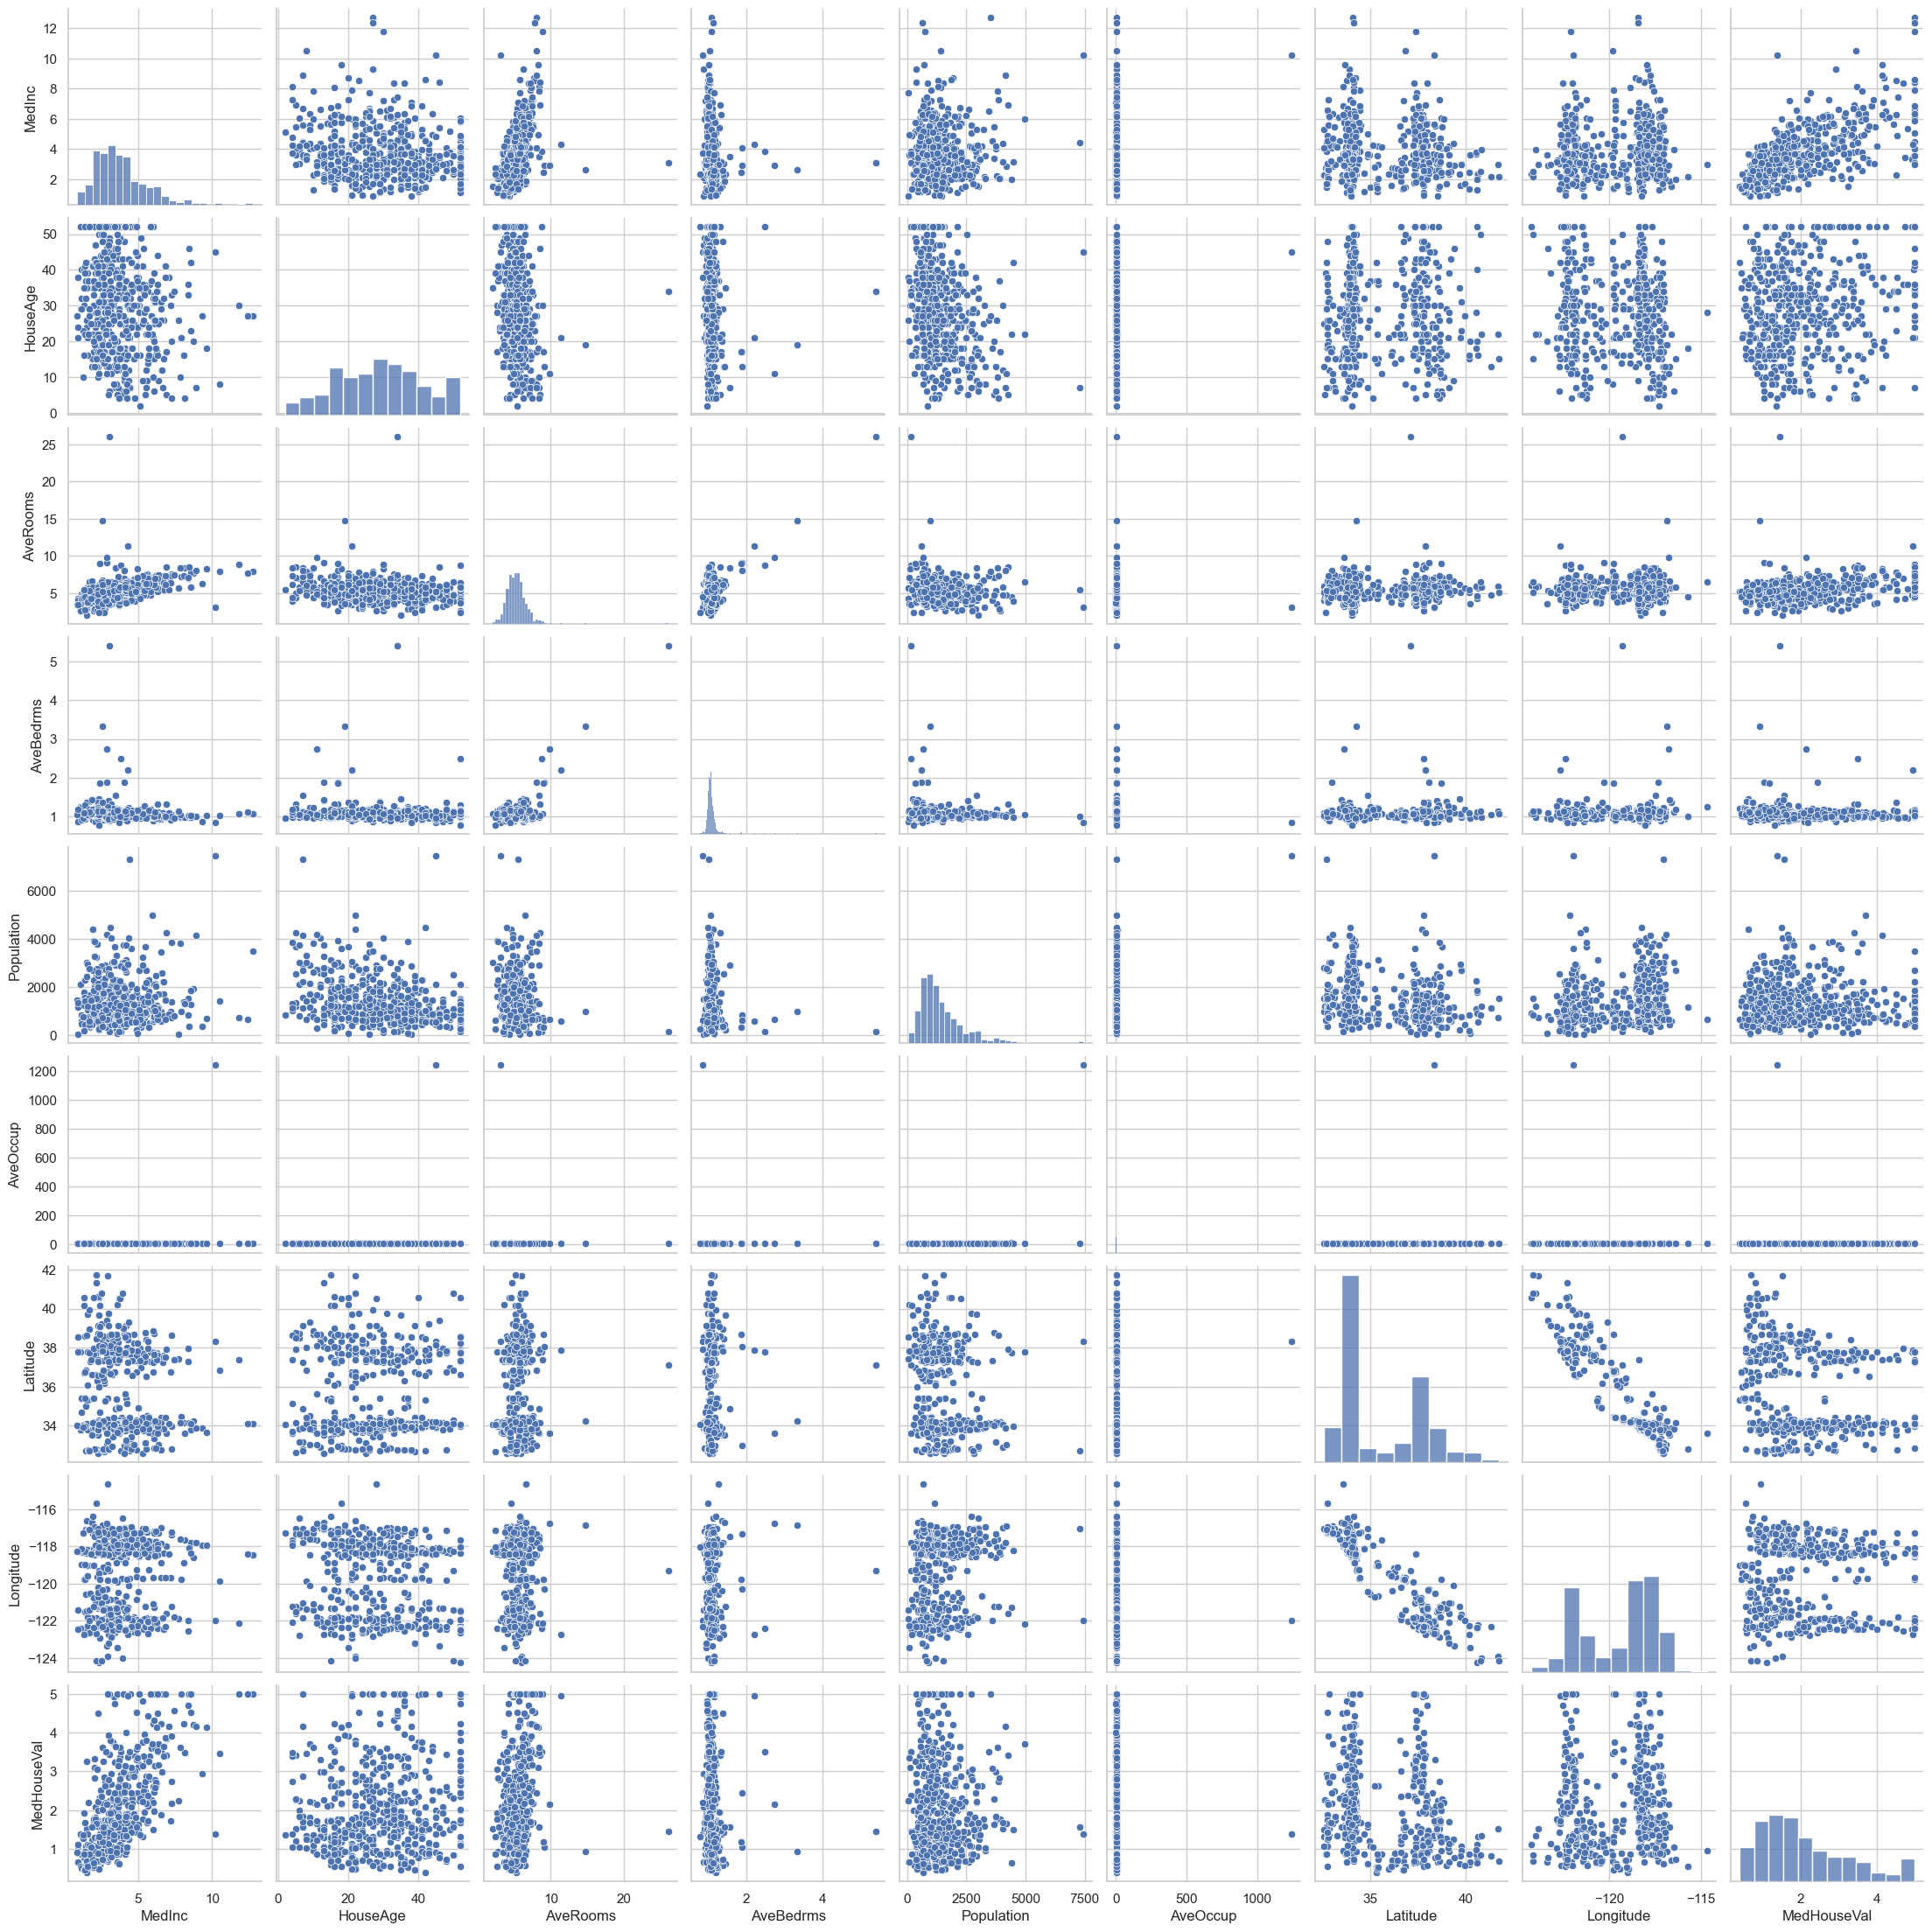

In [21]:
sns.pairplot(df.sample(500))  # sampling for speed
plt.show()

# 🧠 Final Insights

### Key Findings:
- `MedInc` is the most important feature
- Data has no missing values
- Some features are skewed and contain outliers
- Strong potential for feature interactions

### Next Steps:
- Feature Engineering:
  - Income-based interactions
  - Ratio features
- Feature Selection:
  - SHAP
  - Permutation Importance
- Model Building